## 1. Importações

- **pandas**: manipulação e análise de dados tabulares
- **scikit-learn**: algoritmos de ML, pré-processamento, validação e métricas
- **matplotlib / seaborn**: visualização de dados
- **statsmodels**: testes estatísticos auxiliares

In [19]:
import pandas as pd


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix


import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer


## 2. Carregamento dos Dados

Lemos o arquivo `spi_indicators.csv`, que contém indicadores do **Social Progress Index (SPI)**.

O objetivo do modelo será **classificar o nível de renda (`income`)** de cada país com base nesses indicadores.

In [2]:
df = pd.read_csv('spi_indicators.csv')

## 3. Limpeza - INCOME

- Removemos registros com `income = 'Not classified'`, pois não pertencem a nenhuma classe definida e introduziriam ruído.



In [3]:
df = df[df['income'] != 'Not classified']
df.head()



,iso3c,country,region,income,year,population,overall_score,data_use_score,data_services_score,data_products_score,data_sources_score,data_infrastructure_score
0,DNK,Denmark,Europe & Central Asia,High income,2023,5946952,95.255833,100.0,98.466667,90.71250,87.100,100.0
1,FIN,Finland,Europe & Central Asia,High income,2023,5584264,95.115417,100.0,96.433333,90.96875,88.175,100.0
2,POL,Poland,Europe & Central Asia,High income,2023,36685849,94.653750,100.0,97.300000,84.54375,91.425,100.0
3,SWE,Sweden,Europe & Central Asia,High income,2023,10536632,94.410000,100.0,96.000000,90.57500,85.475,100.0
4,ESP,Spain,Europe & Central Asia,High income,2023,48373336,94.325000,100.0,91.200000,92.62500,87.800,100.0


## 4. Separação de Features e Target

Definimos explicitamente quais colunas são **features numéricas** (scores e dados demográficos) e qual é a **feature categórica** (`region`).

- **X**: todas as colunas preditoras (removemos identificadores como `iso3c`, `country` e a variável-alvo)
- **Y**: a variável binária `income_binary` que queremos prever

Separar features e target neste ponto organiza o código e deixa claro o que entra no modelo.

In [4]:
numeric_features = [
    'year', 'population', 'overall_score', 'data_use_score', 
    'data_services_score', 'data_products_score', 
    'data_sources_score', 'data_infrastructure_score'
]
categorical_features = ['region']

X = df.drop(["income", "iso3c", "country"], axis=1)

Y = df['income'] 


## 5. Divisão Treino / Teste

Dividimos os dados em **80% treino** e **20% teste** usando `train_test_split` com `stratify=Y`.

In [5]:
#dividir os treinos
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y)

print("Shape total:", df.shape)
print("Treino:", X_train.shape, "Teste:", X_test.shape)
print("Distribuição (treino):")
print(y_train.value_counts(normalize=True).round(3))

Shape total: (4320, 12)
Treino: (3456, 9) Teste: (864, 9)
Distribuição (treino):
income
High income            0.394
Upper middle income    0.250
Lower middle income    0.236
Low income             0.120
Name: proportion, dtype: float64


## 6. Pipeline de Pré-processamento

Construímos um `ColumnTransformer` com dois pipelines separados:

**Features numéricas:**
1. `SimpleImputer(strategy='median')` — preenche valores ausentes com a mediana da coluna. Usamos mediana (e não média) porque ela é robusta a outliers.
2. `StandardScaler()` — normaliza os valores para média 0 e desvio padrão 1. **Essencial** para Regressão Logística, pois o algoritmo é sensível à escala das features.

**Features categóricas (`region`):**
1. `SimpleImputer(strategy='most_frequent')` — preenche ausentes com a categoria mais frequente.
2. `OneHotEncoder(drop='first')` — converte as categorias em colunas binárias. `drop='first'` remove uma categoria por variável para evitar multicolinearidade perfeita (armadilha das variáveis dummy).

Usar um `Pipeline` garante que o `fit` seja feito apenas nos dados de treino e o `transform` seja aplicado consistentemente ao teste.

In [6]:
numeric_transformer_linear = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) # <-- CRÍTICO AQUI
])

categorical_transformer_linear = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # drop='first' remove a primeira coluna gerada para evitar multicolinearidade (ótimo para LogReg)
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first')) 
])

preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_linear, numeric_features),
        ('cat', categorical_transformer_linear, categorical_features)
    ])

clf_ref_log = Pipeline(steps=[('preprocessor', preprocessor_linear)])



## 7. Definição do Modelo Final

Criamos um `Pipeline` completo: **pré-processamento → classificador**.

Escolhemos `LogisticRegression` com:
- `class_weight='balanced'`: ajusta automaticamente os pesos das classes inversamente proporcional à frequência, compensando o desbalanceamento (64% High vs 36% Low).
- `max_iter=3000`: número elevado de iterações para garantir a convergência do solver.
- `random_state=42`: reprodutibilidade dos resultados.

O `Pipeline` impede *data leakage*: o scaler e o encoder nunca 'veem' os dados de teste durante o treino.

In [7]:
reg_log = LogisticRegression(
    random_state=42,
    max_iter=3000,
    class_weight='balanced'
)

model = Pipeline(
    steps=[
        ("preprocess", preprocessor_linear),
        ("classifier", LogisticRegression(
    random_state=42,
    max_iter=3000,
    class_weight='balanced'))
    ]
)

## 8. Grade de Hiperparâmetros para Busca

Definimos o espaço de busca para o `GridSearchCV`:

- **`penalty`**: tipo de regularização — `l2` (Ridge) penaliza coeficientes grandes; `elasticnet` combina L1 e L2.
- **`C`**: força inversa da regularização — valores pequenos = mais regularização (modelo mais simples/conservador); valores grandes = menos regularização (pode levar a overfitting).
- **`solver`**: algoritmo de otimização — `saga` suporta todos os tipos de penalidade; `lbfgs` só suporta L2.
- **`l1_ratio`**: relevante apenas para `elasticnet`, controla o balanço entre L1 e L2.


In [8]:
param_grid = {
    'classifier__penalty': ['l2', 'elasticnet'],   
    'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],  
    'classifier__solver': ['saga', 'lbfgs'],
    'classifier__l1_ratio': [0.0, 0.3, 0.5, 0.7, 1.0] 
}

## 9. Estratégia de Validação Cruzada

Usamos `StratifiedKFold` com 5 folds e `shuffle=True`.

**5 Folds** , É o padrão mais comum — equilibra bem o viés e a variância da estimativa de desempenho sem custo computacional excessivo.

O `GridSearchCV` com `n_jobs=-1` usa todos os núcleos da CPU disponíveis para paralelizar os 600 treinos (120 combinações × 5 folds).

In [9]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc_ovr',  # pode mudar para 'f1_macro', 'accuracy', etc.
    n_jobs=-1,       
    verbose=2       
)


## 10. Treinamento com Grid Search

Executamos a busca exaustiva. O `GridSearchCV` treina e avalia cada combinação de hiperparâmetros em todos os folds, e ao final re-treina o melhor modelo no conjunto de treino completo (`refit=True` por padrão).

In [10]:
# TREINAR O GRID SEARCH
print("\nIniciando Grid Search com Cross-Validation")
grid_search.fit(X_train, y_train)



Iniciando Grid Search com Cross-Validation
Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\leozi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
150 fits failed out of a total of 600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\leozi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\leozi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\leozi\App

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.001, 0.01, ...], 'classifier__l1_ratio': [0.0, 0.3, ...], 'classifier__penalty': ['l2', 'elasticnet'], 'classifier__solver': ['saga', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc_ovr'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the hi

## 11. Melhores Parâmetros Encontrados

Exibimos a combinação de hiperparâmetros que maximizou a acurácia média na validação cruzada. Esse é o modelo que será usado na avaliação final.

In [11]:
# RESULTADOS DO GRID SEARCH
print("\n" + "="*60)
print("MELHORES PARÂMETROS ENCONTRADOS:")
print("="*60)
print(grid_search.best_params_)
print(f"\nMelhor score de validação cruzada: {grid_search.best_score_:.4f}")


MELHORES PARÂMETROS ENCONTRADOS:
{'classifier__C': 10.0, 'classifier__l1_ratio': 0.3, 'classifier__penalty': 'elasticnet', 'classifier__solver': 'saga'}

Melhor score de validação cruzada: 0.8673


## 12. Avaliação no Conjunto de Teste

Avaliamos o **melhor modelo** encontrado pelo GridSearch no conjunto de teste.

Também calculamos as **probabilidades** (`predict_proba`), úteis para análises de threshold ou curvas ROC.

In [ ]:
#AVALIAÇÃO NO TEST
print("AVALIAÇÃO NO TEST SET")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)  # probabilidades

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia no test set: {test_accuracy:.4f}")

print("\nClassification Report (detalhado):")
print(classification_report(y_test, y_pred))

AVALIAÇÃO NO TEST SET
Acurácia no test set: 0.6146

Classification Report (detalhado):
                     precision    recall  f1-score   support

        High income       0.82      0.75      0.79       340
         Low income       0.47      0.85      0.60       104
Lower middle income       0.49      0.43      0.46       204
Upper middle income       0.54      0.46      0.49       216

           accuracy                           0.61       864
          macro avg       0.58      0.62      0.59       864
       weighted avg       0.63      0.61      0.61       864



## 13. Comparação: Modelo Tunado vs. Modelo Padrão

Para quantificar o ganho real do tuning, treinamos um modelo com parâmetros `default` do sklearn (sem nenhuma customização) e comparamos as acurácias.

Isso responde à pergunta: **valeu a pena gastar tempo e recursos no GridSearch?** Se a melhoria for marginal, pode ser mais vantajoso usar o modelo padrão com regularização simples.

In [13]:
#COMPARAÇÃO COM MODELO PADRÃO (sem tuning)
print("\n" + "="*60)
print("COMPARAÇÃO COM MODELO PADRÃO")
print("="*60)

# Criar modelo padrão (com parâmetros default)
default_model = Pipeline(steps=[
    ('preprocess', preprocessor_linear),
    ('classifier', LogisticRegression(random_state=42, max_iter=3000))
])

# Treinar modelo padrão
default_model.fit(X_train, y_train)
default_pred = default_model.predict(X_test)
default_accuracy = accuracy_score(y_test, default_pred)

print(f"Acurácia do modelo padrão: {default_accuracy:.4f}")
print(f"Acurácia do modelo tunado (GridSearch): {test_accuracy:.4f}")
print(f"Melhoria: {((test_accuracy - default_accuracy) * 100):.2f}%")


COMPARAÇÃO COM MODELO PADRÃO
Acurácia do modelo padrão: 0.6192
Acurácia do modelo tunado (GridSearch): 0.6146
Melhoria: -0.46%


## 14. Colocando lado a lado : Matriz de Confusão

Com a matriz de confusão, podemos ver como o modelo se comporta nos dados de teste e explorar as métricas do modelo padrão x tunado

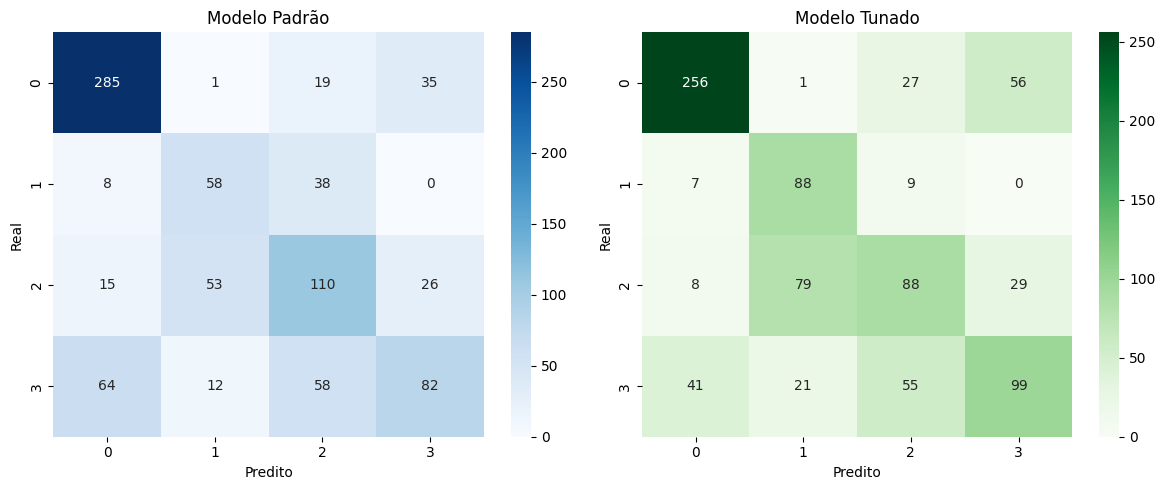

In [20]:
# Matrizes
cm_default = confusion_matrix(y_test, default_pred)
cm_tuned = confusion_matrix(y_test, y_pred)

cm_default = cm_default.astype(int)
cm_tuned = cm_tuned.astype(int)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Modelo padrão 
sns.heatmap(cm_default, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            ax=axes[0])

axes[0].set_title('Modelo Padrão')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

# Modelo tunado 
sns.heatmap(cm_tuned, 
            annot=True, 
            fmt='d', 
            cmap='Greens', 
            ax=axes[1])

axes[1].set_title('Modelo Tunado')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()